In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

In [2]:
from src.graphs import ParallelEdgeGraph, NonDiagonalEdgeGraph, DiagonalEdgeGraph, StaticGraph

/home/psi-boi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


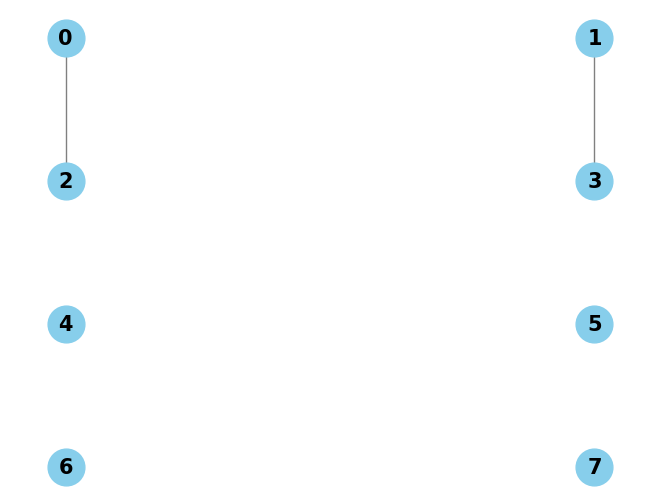

In [3]:
edges = {('000','010'),
         ('001','011')}

G = ParallelEdgeGraph(edges)
G.draw()

In [4]:
print('The Graph Expression: ')
expr = G.expr
display(expr)

The Graph Expression: 


(x_2 & ~x_0) | (~x_0 & ~x_2)

In [5]:
target = G.target
rot_angle = G.rot_angle
print(f'The Target Qubit: {target}')
print(f'We assume a fixed rotation angle: {round(rot_angle, 3)}')

The Target Qubit: 1
We assume a fixed rotation angle: 1.571


The Quantum Circuit: 


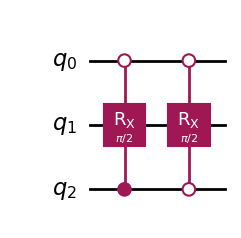

In [6]:
print('The Quantum Circuit: ')
G.get_qc().draw('mpl')

The Quantum Circuit (simplified): 


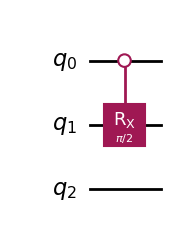

In [7]:
print('The Quantum Circuit (simplified): ')
G.get_qc(simplified=True).draw('mpl')

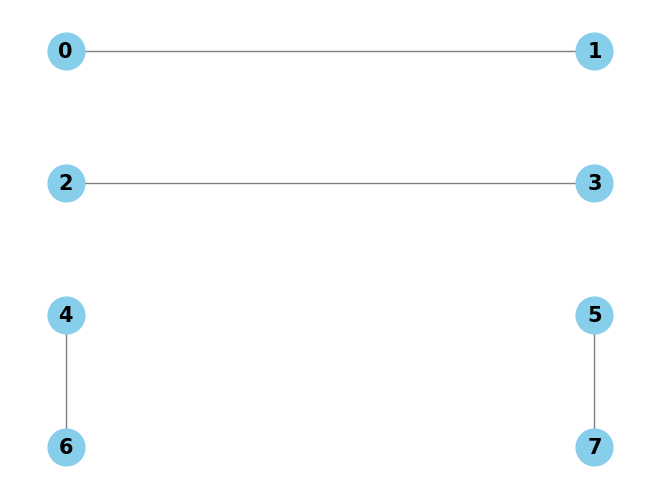

In [35]:
edges = {('000','001'),
         ('010','011'),
         ('100','110'),
         ('101','111')}

G = NonDiagonalEdgeGraph(edges)
G.draw()

The Quantum Circuit: 


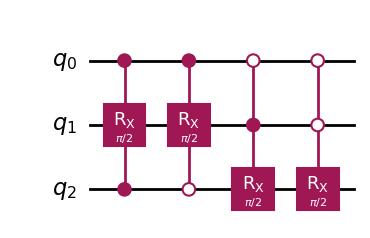

In [36]:
print('The Quantum Circuit: ')
G.get_qc().draw('mpl')

The Quantum Circuit: (simplified)


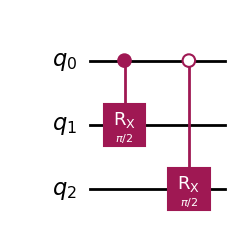

In [37]:
print('The Quantum Circuit: (simplified)')
G_simplified = NonDiagonalEdgeGraph(edges)
G_simplified.get_qc(simplified=True).draw('mpl')

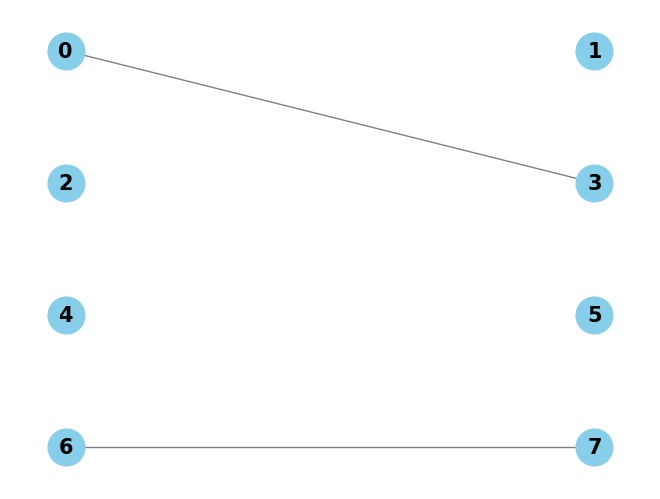

In [11]:
edges = {('000','011'),
         ('110','111')}
G = DiagonalEdgeGraph(edges)
G.draw()

In [12]:
print("Edges with Hamming distance = 1:", G.set_hamming_1)
print("Edges with Hamming distance > 1:", G.set_hamming_greater_1)

Edges with Hamming distance = 1: {('110', '111')}
Edges with Hamming distance > 1: {('000', '011')}


In [13]:
G.edges

{('000', '011'), ('110', '111')}

In [14]:
from src.edges import Edge
from src.misc import get_cyclic_connections

In [15]:
edge = ('00000', '01101')
e = Edge(edge)
e.type

'diagonal'

Target Qubit: 4
CNOTs: [(4, 2), (2, 1)]


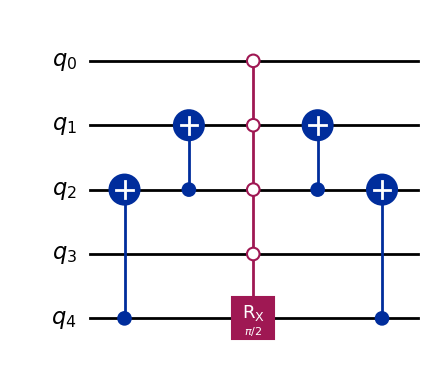

Target Qubit: 2
CNOTs: [(2, 1), (2, 4)]


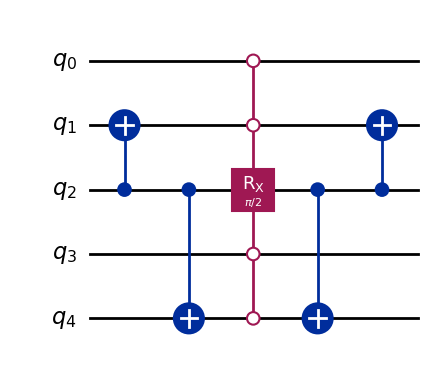

Target Qubit: 1
CNOTs: [(1, 2), (2, 4)]


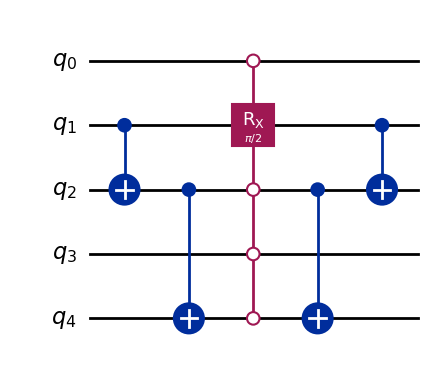

In [16]:
from qiskit import QuantumCircuit

#edge = Edge(('01', '10'))
#edge = Edge(('000', '111'))
edge = Edge(('00000', '01101'))
#edge = Edge(('000', '001'))

possible_candidates = edge.to_possible_edges()
parallel_candidates = edge.get_parallel_candidates()

for e in parallel_candidates:
    edges = set()
    edges.add(e.edge)
    g = ParallelEdgeGraph(edges)
    cnots = get_cyclic_connections(edge.connections, g.target)
    
    circ = QuantumCircuit(g.n_qubits)
    for t in cnots:
        circ.cx(*t)
    circ.append(g.get_qc(), range(g.n_qubits))
    for t in reversed(cnots):
        circ.cx(*t)
        
    print(f'Target Qubit: {g.target}')
    print(f'CNOTs: {cnots}')
    display(circ.decompose().draw('mpl'))

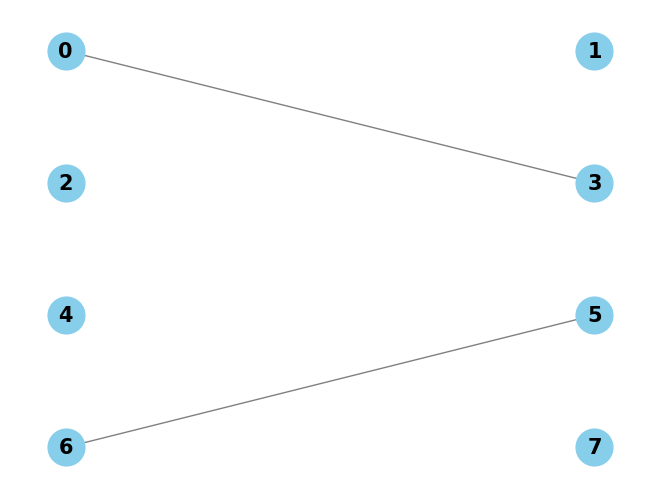

In [29]:
# edges = {('000','011'),
#          ('010','101'),
#          ('110','111')}

# edges = {('000','011'),
#          ('110','111')}

edges = {('000','011'),
         ('101','110')}

G = DiagonalEdgeGraph(edges)
G.draw()

In [30]:
print("Edges with Hamming distance = 1:", G.set_hamming_1)
print("Edges with Hamming distance > 1:", G.set_hamming_greater_1)

Edges with Hamming distance = 1: set()
Edges with Hamming distance > 1: {('101', '110'), ('000', '011')}


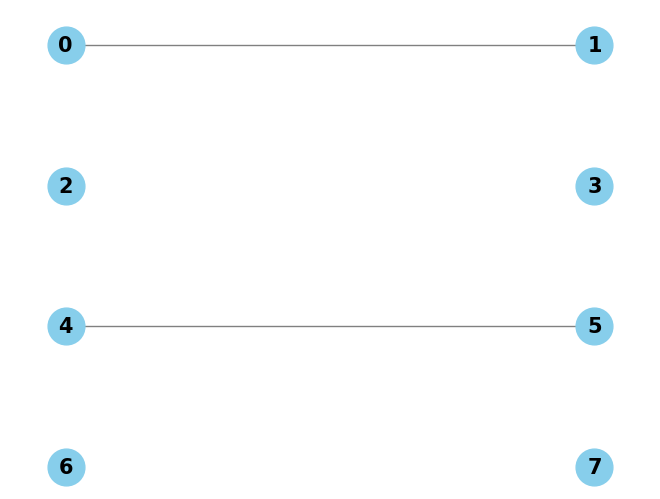

None

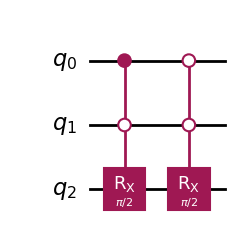

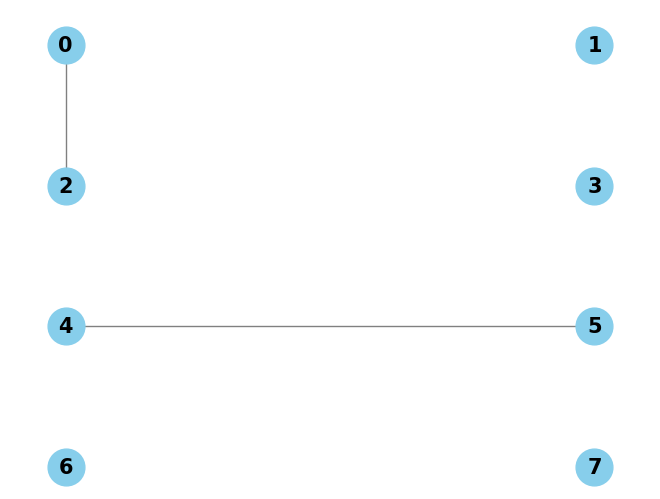

None

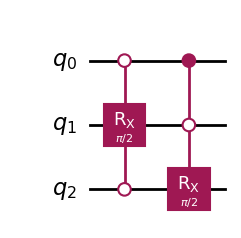

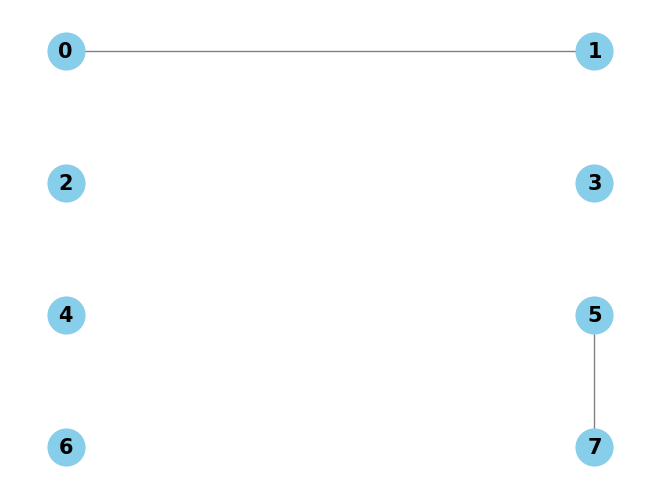

None

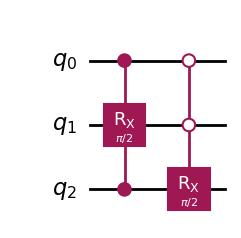

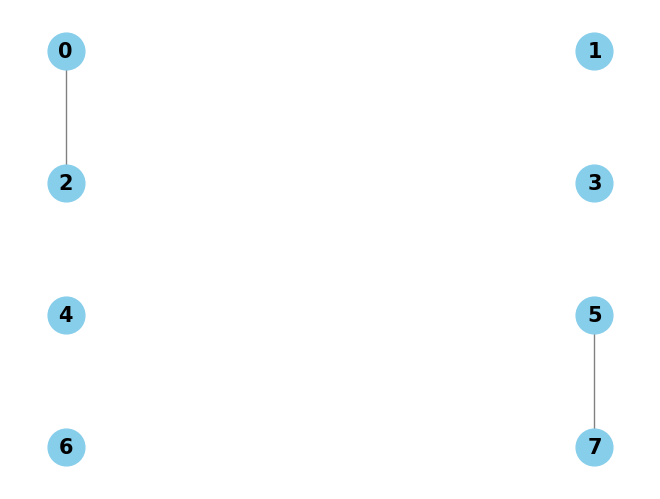

None

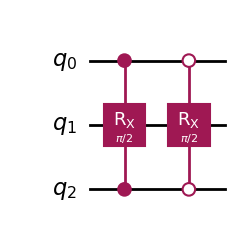

In [34]:
for e in G.candidates:
    display(e.draw())
    display(e.get_qc().draw('mpl'))